In [1]:
from dotenv import load_dotenv
import os

import matplotlib.pyplot as plt
import pandas as pd

from supabase import create_client, Client

In [2]:
load_dotenv()
SUPABASE_URL: str = os.getenv("SUPABASE_URL")
SUPABASE_KEY: str = os.getenv("SUPABASE_KEY")

In [3]:
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

In [4]:
response = supabase.table('rate').select("*").eq('well', 'GUN_436').execute()

In [7]:
df = pd.DataFrame(response.data); df

,id,created_at,well,date,days,formation,otype,fluid,method,choke,orate,wrate,grate
0,46661,2026-06-01T22:32:16.436216+00:00,GUN_436,2009-11-01,6,FLD,production,oil,fountain,NaN,0.000000,0.000000,0.000000
1,46994,2026-06-01T22:32:17.461768+00:00,GUN_436,2009-12-01,31,FLD,production,oil,fountain,NaN,0.000000,0.000000,0.000000
2,47332,2026-06-01T22:32:17.461768+00:00,GUN_436,2010-01-01,31,FLD,production,oil,fountain,NaN,0.000000,0.000000,0.000000
3,47670,2026-06-01T22:32:17.461768+00:00,GUN_436,2010-02-01,11,FLD,production,oil,fountain,NaN,0.000000,0.000000,0.000000
4,48706,2026-06-01T22:32:18.584081+00:00,GUN_436,2010-05-01,31,FLD,production,oil,fountain,NaN,84.032258,0.000000,58.486452
...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,125151,2026-06-01T22:33:22.182699+00:00,GUN_436,2025-03-01,31,FLD,production,oil,gaslift,11.0,63.903226,38.774194,21.002903
182,125397,2026-06-01T22:33:23.165048+00:00,GUN_436,2025-04-01,30,FLD,production,oil,gaslift,11.0,58.333333,40.733333,21.060333
183,125647,2026-06-01T22:33:23.165048+00:00,GUN_436,2025-05-01,31,FLD,production,oil,gaslift,11.0,56.516129,41.129032,20.106129
184,125895,2026-06-01T22:33:23.165048+00:00,GUN_436,2025-06-01,30,FLD,production,oil,gaslift_comp,11.0,54.000000,39.266667,19.113333


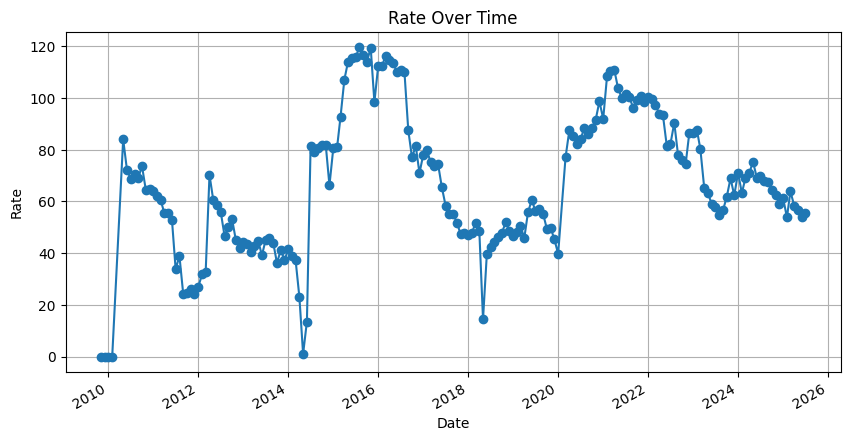

In [5]:
df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["orate"], marker="o", linestyle="-")

# 6. Format the plot
plt.title("Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.grid(True)
plt.gcf().autofmt_xdate()  # Rotates date labels automatically

plt.show()
